# Shendure MWU power — all cell types

Assesses MWU power (TPR) as a function of CRE_oi strength relative to `minP`, for every cell type in the Shendure dataset.

For each cell type:
1. Draw `n_cres` synthetic CREs from uniform(min, max), with one fixed at `minP` as the reference
2. Simulate `cells_per_cell_type` cells (matching the real count for that cell type) across `n_sims` replicates, repeated 100 times
3. Run MWU for all CREs vs. reference
4. Aggregate and plot per-cell-type power curves

Each cell type is simulated independently with its own empirical `(n_cres, cell_count)` pair.
`one_library_replicate` now accepts a `cell_type` parameter so real names flow through cleanly.

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
data_root = Path("/gpfs/gibbs/pi/reilly/tabula_data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
sim_date = "2026-03-18"

In [3]:

local = False
if local:
    cluster = LocalCluster(memory_limit='48G')
    client = Client(cluster)
else:
    cluster = SLURMCluster(
        cores=3,
        memory="16G",
        processes=3,          # 1 process per core: 3 workers per job, fixes GIL bottleneck
        worker_extra_args=["--nthreads", "2"],  # deadlock headroom
        job_extra_directives=[
            "-p ycga",
            "--job-name=simclust_worker",
            "--time=6:00:00",
            "--output=worker_%j.out"
        ]
    )
    cluster.scale(jobs=10)  # 10 jobs x 3 workers = 30 workers total
    client = Client(
        cluster,
        timeout=f"{5*60}s",
        heartbeat_interval="20s"
    )
print(client.dashboard_link, flush=True)


http://10.178.138.34:8787/status


In [4]:
import pickle

# Load per-cell-type n_cres from the ortho parameters (avoids loading the full
# ortho object, which has lazy file references to the training data).
with open(data_root / "shendure" / "shendure_ortho_20260306" / "by_cell_type_parameters.pkl", "rb") as f:
    _params = pickle.load(f)

cell_types = sorted(_params.nb.keys())
n_cres_per_ct = {ct: len(_params.nb[ct]) for ct in cell_types}
del _params

print("Cell types and parameters:")
for ct in cell_types:
    cells = scm.SHENDURE_BOUNDS.cells_per_cell_type.get(ct, "N/A")
    print(f"  {ct}: n_cres={n_cres_per_ct[ct]}, cells={cells}")


Cell types and parameters:
  Cardiomyocytes: n_cres=79, cells=680
  EpiblastPrimitiveStreak: n_cres=185, cells=3445
  ExEndodermParietal: n_cres=178, cells=4644
  ExEndodermVisceral: n_cres=148, cells=3238
  Haematoendothelial: n_cres=91, cells=1079
  Mesoderm: n_cres=177, cells=7427
  NeuroectodermBrain: n_cres=173, cells=7750
  NeuroectodermRostral: n_cres=85, cells=1757
  SurfaceEctoderm: n_cres=139, cells=5168
  reference: n_cres=207, cells=8201


In [5]:
max_activity = 0.05
min_activity = scm.SHENDURE_BOUNDS.min_mpra_umi
minP = scm.SHENDURE_BOUNDS.reference_activity
n_library_reps = 100
n_sims = 5
print(f"minP={minP:.6f}, min={min_activity:.6f}, max={max_activity}")

minP=0.019311, min=0.003474, max=0.05


In [6]:
all_sims = {}  # {cell_type: [sim, ...]}

for cell_type in cell_types:
    print(f"\n=== {cell_type} ===", flush=True)

    bound_ct = scm.SHENDURE_BOUNDS.copy()
    bound_ct.cells_per_cell_type = scm.SHENDURE_BOUNDS.cells_per_cell_type.loc[[cell_type]]
    ct_dir = data_root / f"{sim_date}_shendure_pow" / cell_type

    # Resume: reload already-complete sims from disk
    sims_ct = []
    if ct_dir.exists():
        for d in sorted(ct_dir.iterdir()):
            mwu_dir = d / "tests" / "hs_all_ct" / "mwu"
            if mwu_dir.exists() and any(mwu_dir.iterdir()):
                sims_ct.append(scm.de_novo_simulation(location=ct_dir, name=d.name, client=client))
    print(f"  Resumed {len(sims_ct)} sims from disk.", flush=True)

    # Run any remaining reps
    n_remaining = n_library_reps - len(sims_ct)
    print(f"  Running {n_remaining} fresh sims.", flush=True)
    for i in range(n_remaining):
        _, sim = scm.one_library_replicate(
            root=ct_dir,
            n_sims=n_sims,
            client=client,
            flatten_overtransfection=False,
            bound=bound_ct,
            n_cres=n_cres_per_ct[cell_type],
            min=min_activity,
            max=max_activity,
            minP=minP,
            cell_type=cell_type,
        )
        sims_ct.append(sim)

    all_sims[cell_type] = sims_ct
    print(f"  {len(sims_ct)} replicates ready.", flush=True)



=== Cardiomyocytes ===


scMPRAforge: INFO: 'state.parquet' found for 'sim_010b9e06', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_056b70e8', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_0bed6929', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_0c228464', loading.


...

scMPRAforge: INFO: 'state.parquet' found for 'sim_faf49ec5', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_fed371bd', loading.


  Resumed 100 sims from disk.


  Running 0 fresh sims.


  100 replicates ready.


In [7]:
for sims in all_sims.values():
    for sim in sims:
        sim.save()
print("Saved.", flush=True)

Saved.


In [8]:
# Build a hypothesis set per cell type and run MWU (skip if already done).
for cell_type, sims in all_sims.items():
    print(f"MWU: {cell_type}", flush=True)
    hs = None
    for sim in sims:
        mwu_dir = sim.location / sim.name / "tests" / "hs_all_ct" / "mwu"
        if mwu_dir.exists() and any(mwu_dir.iterdir()):
            continue  # already done
        if hs is None:
            example = scm.scMPRA_data.from_parquet(sim.scmpradatp / "0.scmpra")
            hs = scm.make_all_by_celltype_hypotheses(counts=example, reference_cre="reference")
        sim.add_hypothesis_set("hs_all_ct", hs)
        sim.mwu("hs_all_ct")
        sim.save()

for sims in all_sims.values():
    for sim in sims:
        sim.save()
print("MWU done and saved.", flush=True)


MWU: Cardiomyocytes


MWU: EpiblastPrimitiveStreak


MWU: ExEndodermParietal


MWU: ExEndodermVisceral


MWU: Haematoendothelial


...

MWU: NeuroectodermBrain


MWU: NeuroectodermRostral


MWU: SurfaceEctoderm


MWU: reference


MWU done and saved.


In [9]:
all_mergy = {
    ct: scm.sum_pow(sims, hypothesis_set_name="hs_all_ct", test_type="mwu")
    for ct, sims in all_sims.items()
}

Saved: output/power_mwu_all_cell_types.svg


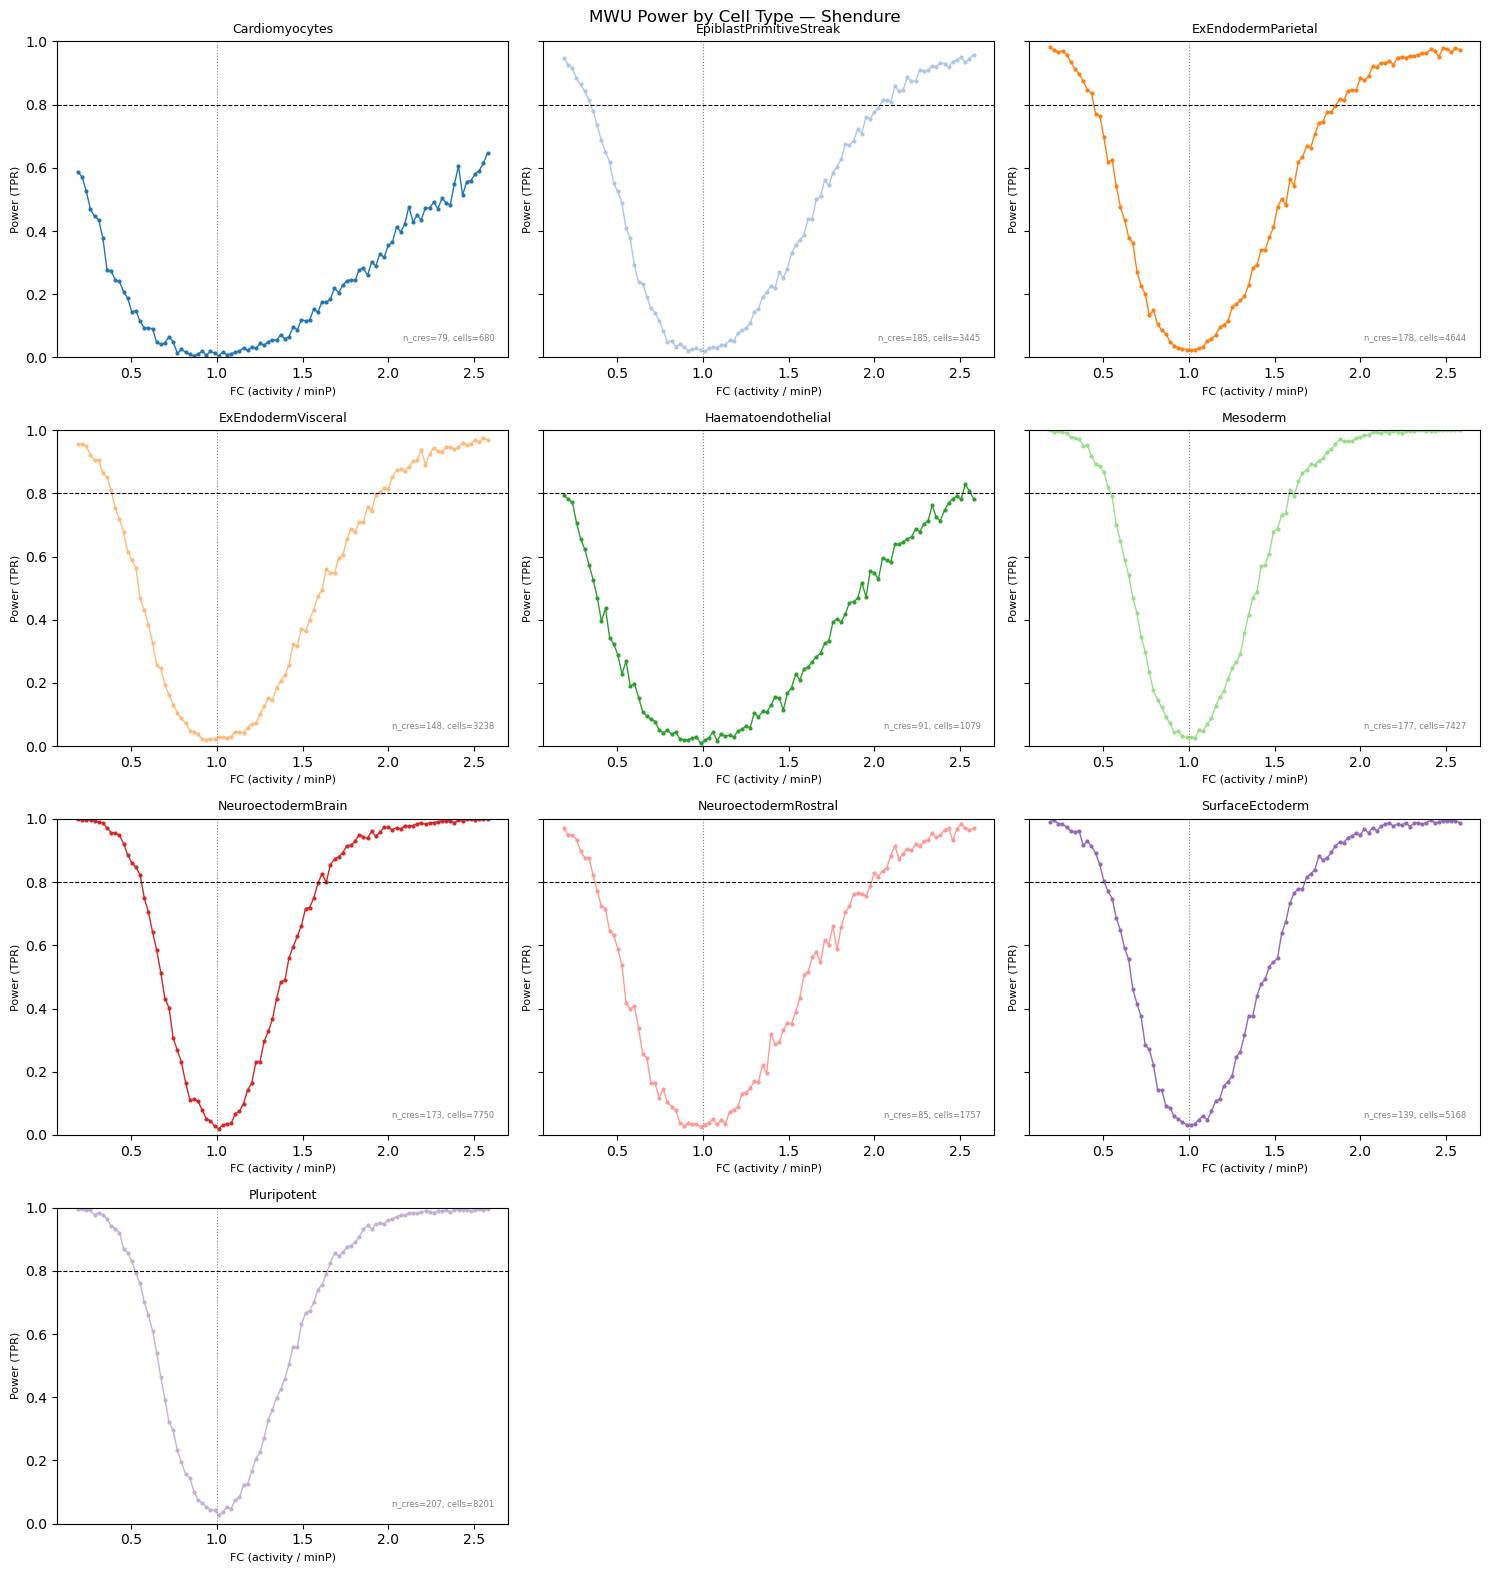

In [10]:
def _pow_curve_data(mergy, n_bins=100):
    df = mergy.copy()
    df["fc"] = pd.cut(df["fc"], bins=n_bins)
    binned = (
        df.groupby("fc", observed=True)["reject_null"]
        .mean()
        .reset_index(name="reject_frac")
    )
    binned["bin_center"] = binned["fc"].apply(lambda x: x.mid)
    return binned

ncols = 3
nrows = math.ceil(len(cell_types) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten()
palette = sns.color_palette("tab20", n_colors=len(cell_types))

for i, cell_type in enumerate(cell_types):
    cell_type_display = "Pluripotent" if cell_type == "reference" else cell_type
    binned = _pow_curve_data(all_mergy[cell_type])
    ax = axes[i]
    ax.plot(binned["bin_center"], binned["reject_frac"],
            color=palette[i], marker="o", markersize=2, linewidth=1)
    ax.axhline(0.8, color="black", linestyle="--", lw=0.8)
    ax.axvline(1.0, color="grey", linestyle=":", lw=0.8)
    ax.set_title(cell_type_display, fontsize=9)
    ax.set_xlabel("FC (activity / minP)", fontsize=8)
    ax.set_ylabel("Power (TPR)", fontsize=8)
    ax.set_ylim(0, 1)
    cells = scm.SHENDURE_BOUNDS.cells_per_cell_type.get(cell_type, "?")
    ax.text(0.97, 0.05,
            f"n_cres={n_cres_per_ct[cell_type]}, cells={cells}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=6, color="grey")

for j in range(len(cell_types), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("MWU Power by Cell Type — Shendure", fontsize=12)
plt.tight_layout()
svg_path = output_dir / "power_mwu_all_cell_types.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
print(f"Saved: {svg_path}")
plt.show()

In [11]:
client.close()
cluster.close()